# InSIGHT — Ensemble Detector 성능 리포트

**모델:** `haywoodsloan/ai-image-detector-deploy (w=0.6)` + `Organika/sdxl-detector (w=0.4)`  
**전략:** 소프트 보팅 (가중 평균, threshold=0.5)  
**작성자:** woochul  
**실험 일시:** 2026-05-11  
**데이터셋:** AI 생성 이미지 101장 / 실제 인물 사진 249장 (총 350장, 실패 1장 제외 349장)  

---

### 평가 목표치
| 지표 | 목표 | 방향 |
|---|---|---|
| Accuracy | 70% 이상 | ↑ |
| Precision | 75% 이상 | ↑ |
| Recall ★ | 75% 이상 (핵심) | ↑ |
| F1 Score | 70% 이상 | ↑ |
| FPR | 20% 이하 | ↓ |
| Avg Inference Time | 3초 이하 | ↓ |

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family']      = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

COLOR_PASS      = '#2ecc71'
COLOR_FAIL      = '#e74c3c'
COLOR_ENSEMBLE  = '#9B59B6'   # 보라 — 앙상블
COLOR_DEPLOY    = '#3498db'   # 파랑 — deploy 단독
COLOR_SDXL      = '#1ABC9C'   # 청록 — sdxl 단독
COLOR_TARGET    = '#f39c12'
COLOR_AI        = '#e74c3c'
COLOR_REAL      = '#3498db'

BENCH_DIR = os.path.dirname(os.path.abspath('__file__'))

TARGET = {
    'accuracy' : 70.0,
    'precision': 75.0,
    'recall'   : 75.0,
    'f1'       : 70.0,
    'fpr'      : 20.0,
    'avg_time' :  3.0,
}

# ── 앙상블 결과 로드 ──
csv_path = os.path.join(BENCH_DIR, 'ensemble_results_20260511_094857.csv')
df = pd.read_csv(csv_path)
m  = df.iloc[0].to_dict()
for k in ['accuracy','precision','recall','f1','fpr','avg_time','tp','fp','fn','tn']:
    m[k] = float(m[k])
tp, fp, fn, tn = int(m['tp']), int(m['fp']), int(m['fn']), int(m['tn'])
total = tp + fp + fn + tn

# ── 단일 모델 기준값 ──
DEPLOY = {'label': 'deploy (단독)',
          'accuracy':88.25,'precision':75.86,'recall':87.13,
          'f1':81.11,'fpr':11.29,'avg_time':0.828,
          'tp':88,'fp':28,'fn':13,'tn':220}
SDXL   = {'label': 'sdxl (단독)',
          'accuracy':77.08,'precision':59.13,'recall':67.33,
          'f1':62.96,'fpr':18.95,'avg_time':0.449,
          'tp':68,'fp':47,'fn':33,'tn':201}

print(f'앙상블 결과 로드 완료')
print(f'TP={tp}  FP={fp}  FN={fn}  TN={tn}  (N={total})')
print(f'Accuracy={m["accuracy"]:.2f}%  Precision={m["precision"]:.2f}%  Recall={m["recall"]:.2f}%')
print(f'F1={m["f1"]:.2f}%  FPR={m["fpr"]:.2f}%  Avg Time={m["avg_time"]:.3f}s')

앙상블 결과 로드 완료
TP=92  FP=26  FN=9  TN=222  (N=349)
Accuracy=89.97%  Precision=77.97%  Recall=91.09%
F1=84.02%  FPR=10.48%  Avg Time=0.694s


---
## 1. 핵심 지표 요약

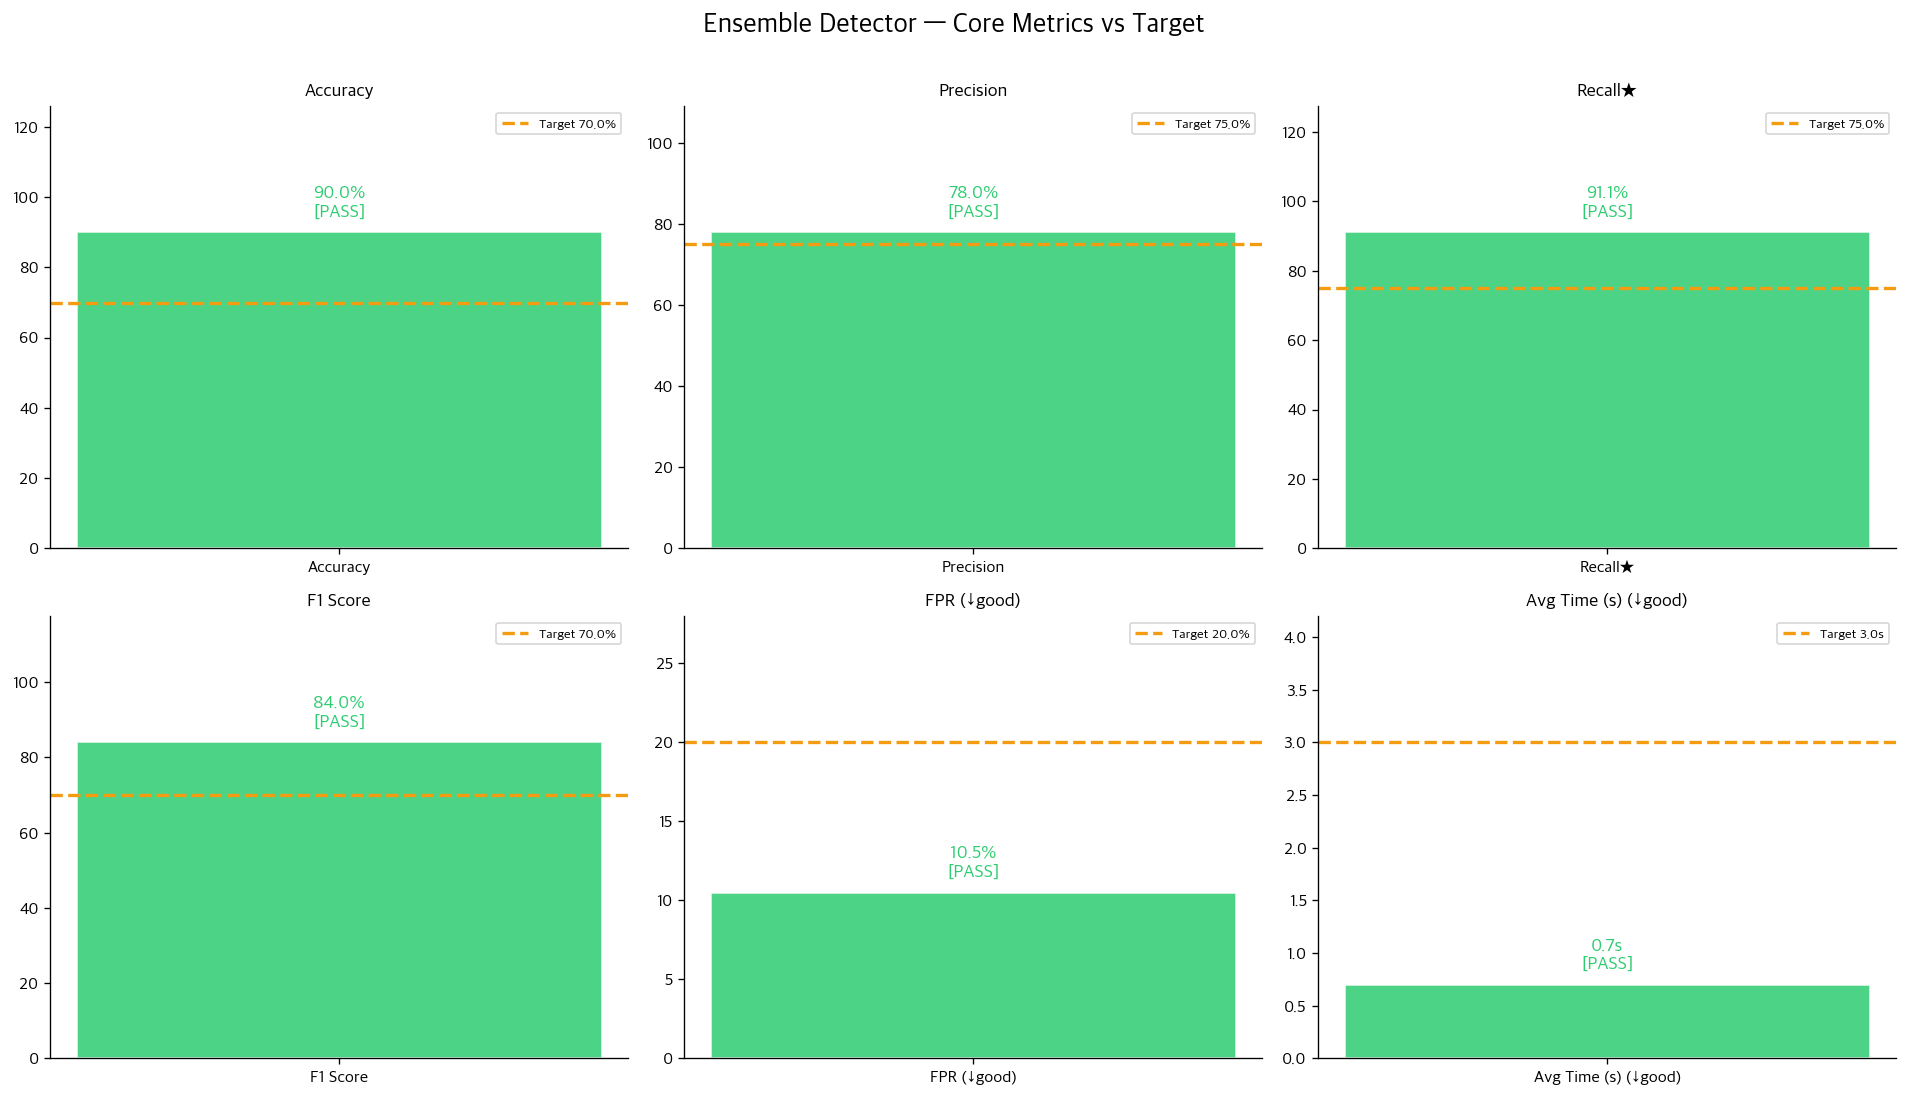

In [2]:
metrics       = ['accuracy','precision','recall','f1','fpr','avg_time']
metric_labels = ['Accuracy','Precision','Recall★','F1 Score','FPR (↓good)','Avg Time (s) (↓good)']
lower_better  = [False, False, False, False, True, True]

vals    = [m[k] for k in metrics]
targets = [TARGET[k] for k in metrics]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Ensemble Detector — Core Metrics vs Target', fontsize=16, fontweight='bold', y=1.01)

for ax, metric, label, val, target, lower in zip(
        axes.flat, metrics, metric_labels, vals, targets, lower_better):
    ok    = (val <= target) if lower else (val >= target)
    color = COLOR_PASS if ok else COLOR_FAIL
    unit  = 's' if 'time' in metric else '%'
    ax.bar([label], [val], color=color, alpha=0.85, edgecolor='white', width=0.5)
    ax.axhline(target, color=COLOR_TARGET, linestyle='--', linewidth=2,
               label=f'Target {target}{unit}')
    ax.set_ylim(0, max(val, target) * 1.4)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    badge = 'PASS' if ok else 'FAIL'
    ax.text(0, val + max(val, target)*0.05,
            f'{val:.1f}{unit}\n[{badge}]', ha='center', fontsize=11,
            fontweight='bold', color=COLOR_PASS if ok else COLOR_FAIL)

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR,'charts','ensemble_core_metrics.png'), bbox_inches='tight', dpi=150)
plt.show()

---
## 2. 목표치 달성 현황표

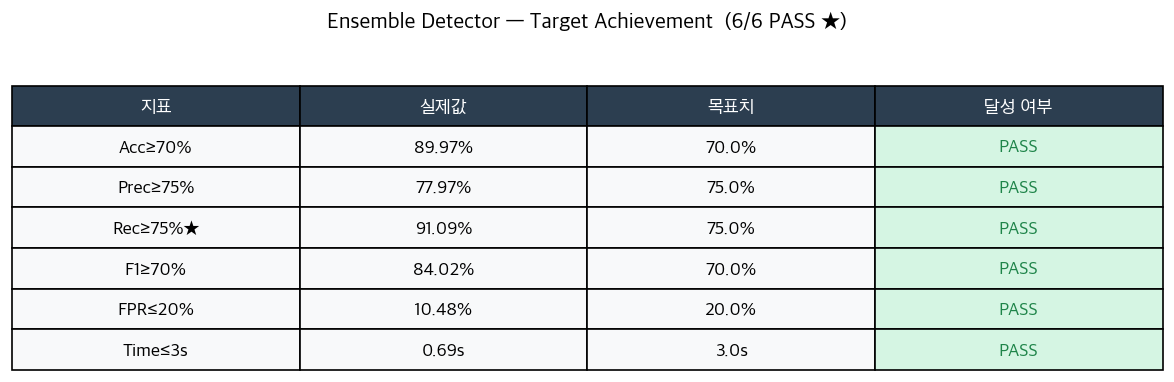

총 6/6 항목 목표 달성


In [3]:
check_cfg = [
    ('Acc≥70%',   'accuracy',  70.0, False),
    ('Prec≥75%',  'precision', 75.0, False),
    ('Rec≥75%★',  'recall',    75.0, False),
    ('F1≥70%',    'f1',        70.0, False),
    ('FPR≤20%',   'fpr',       20.0, True),
    ('Time≤3s',   'avg_time',   3.0, True),
]
row_data = []; pass_cnt = 0
for col_label, metric, tgt, lower in check_cfg:
    val = m[metric]; ok = (val <= tgt) if lower else (val >= tgt)
    pass_cnt += int(ok); unit = 's' if 'time' in metric else '%'
    row_data.append([col_label, f'{val:.2f}{unit}', f'{tgt}{unit}', 'PASS' if ok else 'FAIL'])

fig, ax = plt.subplots(figsize=(10, 3)); ax.axis('off')
tbl = ax.table(cellText=row_data,
               colLabels=['지표','실제값','목표치','달성 여부'],
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.3, 2.2)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', fontweight='bold')
    elif c == 3:
        t = cell.get_text().get_text()
        cell.set_facecolor('#d5f5e3' if t=='PASS' else '#fadbd8')
        cell.set_text_props(color='#1e8449' if t=='PASS' else '#922b21', fontweight='bold')
    else:
        cell.set_facecolor('#f8f9fa')
fig.suptitle(f'Ensemble Detector — Target Achievement  ({pass_cnt}/6 PASS ★)',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR,'charts','ensemble_target_table.png'), bbox_inches='tight', dpi=150)
plt.show()
print(f'총 {pass_cnt}/6 항목 목표 달성')

---
## 3. 혼동 행렬 (Confusion Matrix)

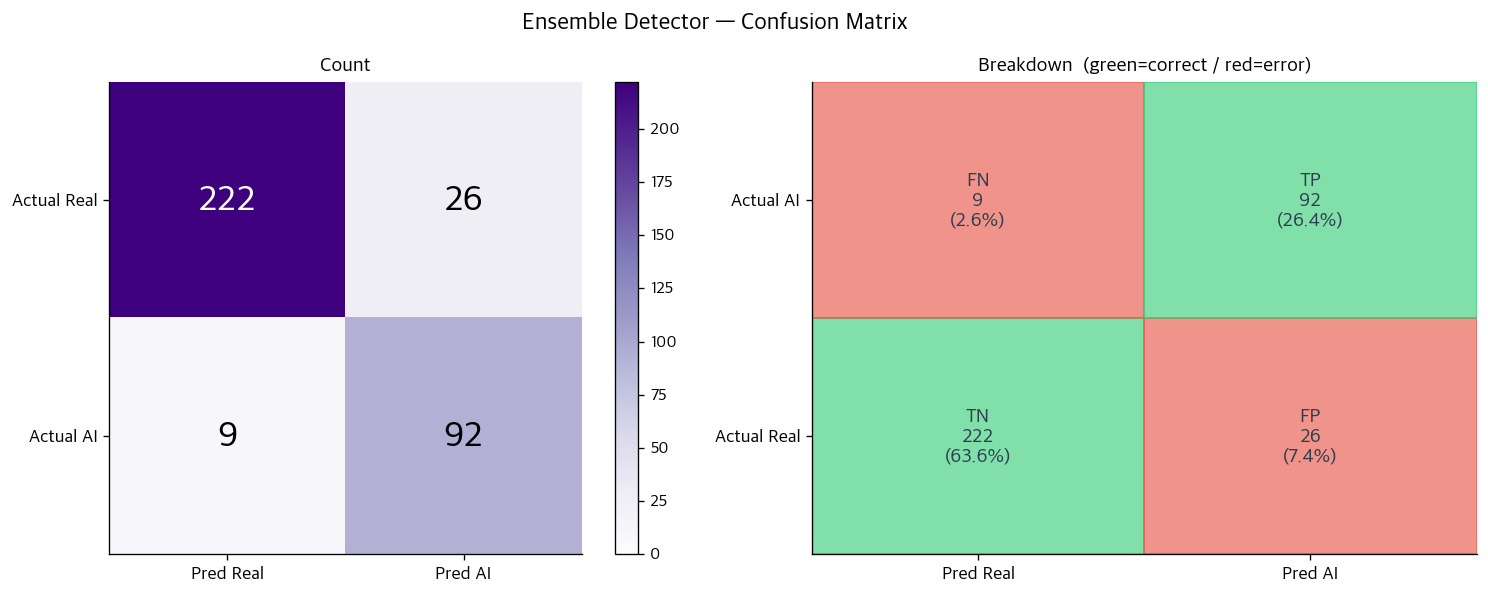

TP (AI 정탐)   : 92  (91.1% of AI images)
FN (AI 미탐)   : 9  (8.9% of AI images)
FP (Real 오탐) : 26  (10.5% of Real images)
TN (Real 정탐) : 222  (89.5% of Real images)


In [4]:
cm = np.array([[tn, fp], [fn, tp]])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Ensemble Detector — Confusion Matrix', fontsize=14, fontweight='bold')

ax = axes[0]
im = ax.imshow(cm, cmap='Purples', vmin=0)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred Real','Pred AI'], fontsize=11)
ax.set_yticklabels(['Actual Real','Actual AI'], fontsize=11)
ax.set_title('Count', fontsize=12, fontweight='bold')
for r in range(2):
    for c in range(2):
        ax.text(c, r, str(cm[r,c]), ha='center', va='center', fontsize=22, fontweight='bold',
                color='white' if cm[r,c] > cm.max()*0.5 else 'black')
plt.colorbar(im, ax=ax)

ax = axes[1]
labels_pct = np.array([
    [f'TN\n{tn}\n({tn/total*100:.1f}%)', f'FP\n{fp}\n({fp/total*100:.1f}%)'],
    [f'FN\n{fn}\n({fn/total*100:.1f}%)', f'TP\n{tp}\n({tp/total*100:.1f}%)']
])
colors_map = np.array([[COLOR_PASS, COLOR_FAIL],[COLOR_FAIL, COLOR_PASS]])
for r in range(2):
    for c in range(2):
        ax.add_patch(plt.Rectangle([c-0.5, r-0.5], 1, 1, color=colors_map[r,c], alpha=0.6))
        ax.text(c, r, labels_pct[r,c], ha='center', va='center',
                fontsize=12, fontweight='bold', color='#2c3e50')
ax.set_xlim(-0.5,1.5); ax.set_ylim(-0.5,1.5)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred Real','Pred AI'], fontsize=11)
ax.set_yticklabels(['Actual Real','Actual AI'], fontsize=11)
ax.set_title('Breakdown  (green=correct / red=error)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR,'charts','ensemble_confusion.png'), bbox_inches='tight', dpi=150)
plt.show()

n_ai   = tp + fn
n_real = fp + tn
print(f'TP (AI 정탐)   : {tp}  ({tp/n_ai*100:.1f}% of AI images)')
print(f'FN (AI 미탐)   : {fn}  ({fn/n_ai*100:.1f}% of AI images)')
print(f'FP (Real 오탐) : {fp}  ({fp/n_real*100:.1f}% of Real images)')
print(f'TN (Real 정탐) : {tn}  ({tn/n_real*100:.1f}% of Real images)')

---
## 4. 단일 모델 vs 앙상블 — 3자 비교

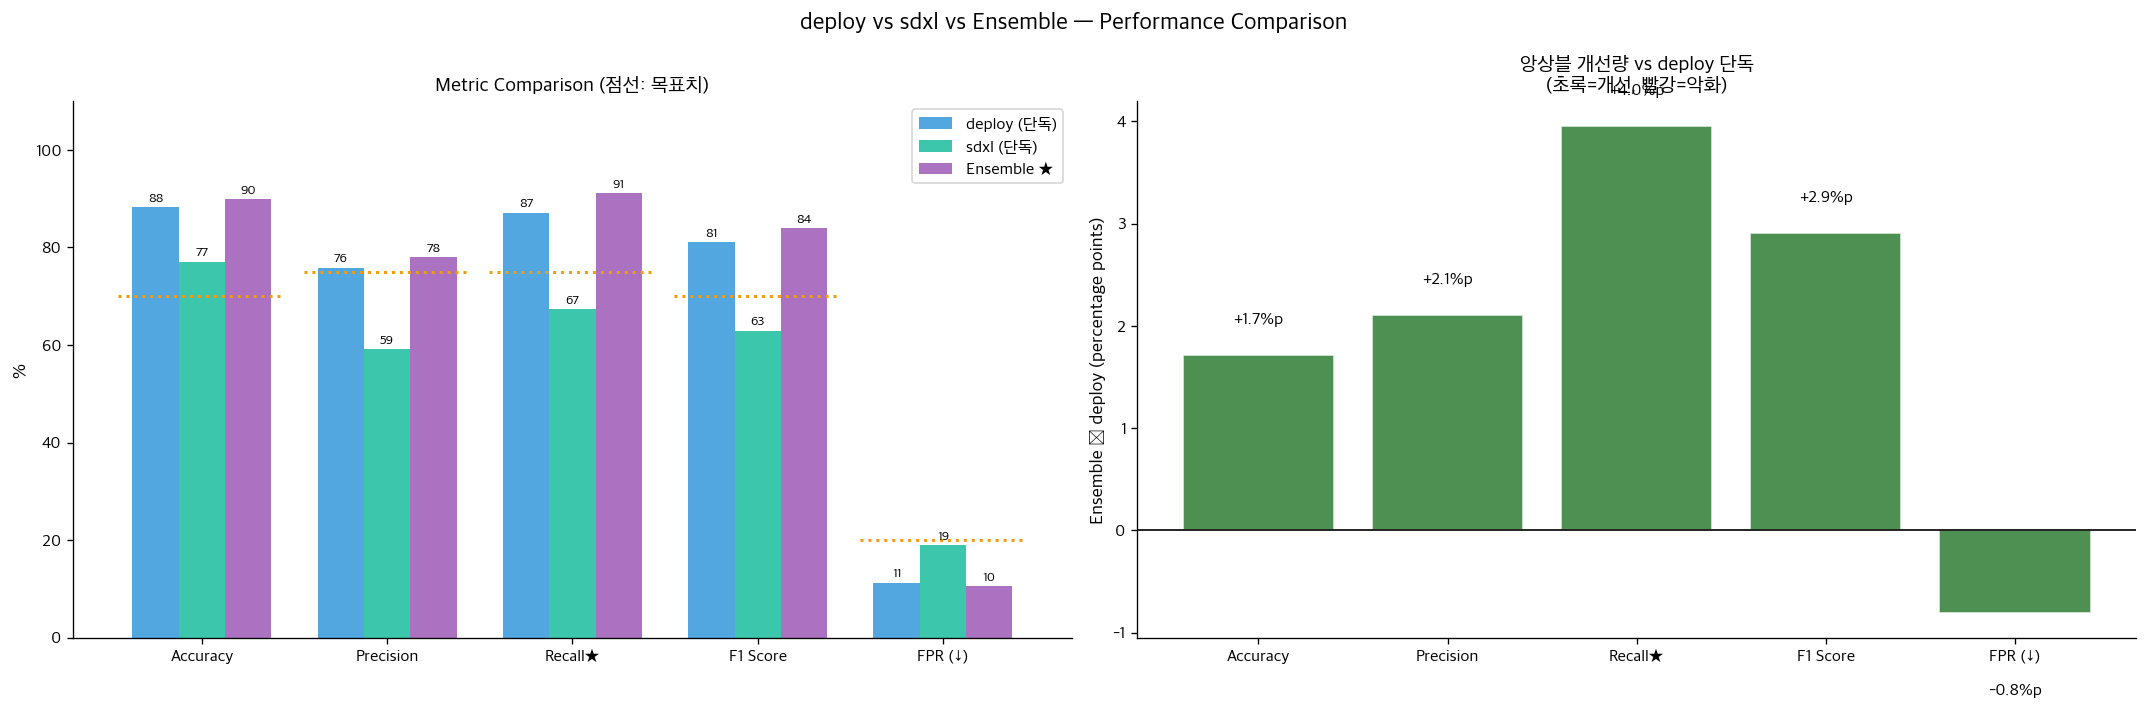


[앙상블 vs deploy 비교]
  Accuracy      : deploy=88.2%  ensemble=90.0%  (+1.7%p)
  Precision     : deploy=75.9%  ensemble=78.0%  (+2.1%p)
  Recall★       : deploy=87.1%  ensemble=91.1%  (+4.0%p)
  F1 Score      : deploy=81.1%  ensemble=84.0%  (+2.9%p)
  FPR (↓)       : deploy=11.3%  ensemble=10.5%  (-0.8%p)


In [5]:
cmp_metrics = ['accuracy','precision','recall','f1','fpr']
cmp_labels  = ['Accuracy','Precision','Recall★','F1 Score','FPR (↓)']
tgt_vals    = [TARGET[k] for k in cmp_metrics]

deploy_vals   = [DEPLOY[k] for k in cmp_metrics]
sdxl_vals     = [SDXL[k]   for k in cmp_metrics]
ensemble_vals = [m[k]       for k in cmp_metrics]

x = np.arange(len(cmp_metrics)); w = 0.25

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('deploy vs sdxl vs Ensemble — Performance Comparison', fontsize=14, fontweight='bold')

# 막대 그래프
ax = axes[0]
b1 = ax.bar(x - w,   deploy_vals,   w, label='deploy (단독)',  color=COLOR_DEPLOY,   alpha=0.85)
b2 = ax.bar(x,       sdxl_vals,     w, label='sdxl (단독)',    color=COLOR_SDXL,     alpha=0.85)
b3 = ax.bar(x + w,   ensemble_vals, w, label='Ensemble ★',     color=COLOR_ENSEMBLE, alpha=0.85)
for xi, tv in zip(x, tgt_vals):
    ax.hlines(tv, xi-0.45, xi+0.45, colors=COLOR_TARGET, linestyles=':', linewidth=1.8)
ax.set_xticks(x); ax.set_xticklabels(cmp_labels, fontsize=10)
ax.set_ylim(0, 110); ax.set_ylabel('%', fontsize=11)
ax.set_title('Metric Comparison (점선: 목표치)', fontweight='bold')
ax.legend(fontsize=10)
for bars in (b1, b2, b3):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.8,
                f'{h:.0f}', ha='center', va='bottom', fontsize=8)

# 앙상블 개선량 (vs deploy)
ax = axes[1]
deltas = [ensemble_vals[i] - deploy_vals[i] for i in range(len(cmp_metrics))]
colors_d = ['#2E7D32' if (d>=0 and k!='fpr') or (d<=0 and k=='fpr') else '#C62828'
            for d, k in zip(deltas, cmp_metrics)]
bars_d = ax.bar(cmp_labels, deltas, color=colors_d, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('Ensemble − deploy (percentage points)', fontsize=11)
ax.set_title('앙상블 개선량 vs deploy 단독\n(초록=개선, 빨강=악화)', fontweight='bold')
for bar, val in zip(bars_d, deltas):
    sign = '+' if val >= 0 else ''
    ax.text(bar.get_x()+bar.get_width()/2, val+(0.3 if val>=0 else -0.8),
            f'{sign}{val:.1f}%p', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR,'charts','ensemble_vs_single.png'), bbox_inches='tight', dpi=150)
plt.show()

print('\n[앙상블 vs deploy 비교]')
for lbl, met, ev, dv in zip(cmp_labels, cmp_metrics, ensemble_vals, deploy_vals):
    diff = ev - dv; sign = '+' if diff>=0 else ''
    print(f'  {lbl:<14}: deploy={dv:.1f}%  ensemble={ev:.1f}%  ({sign}{diff:.1f}%p)')

---
## 5. TP/FP/FN/TN 변화 분석 (앙상블 효과)

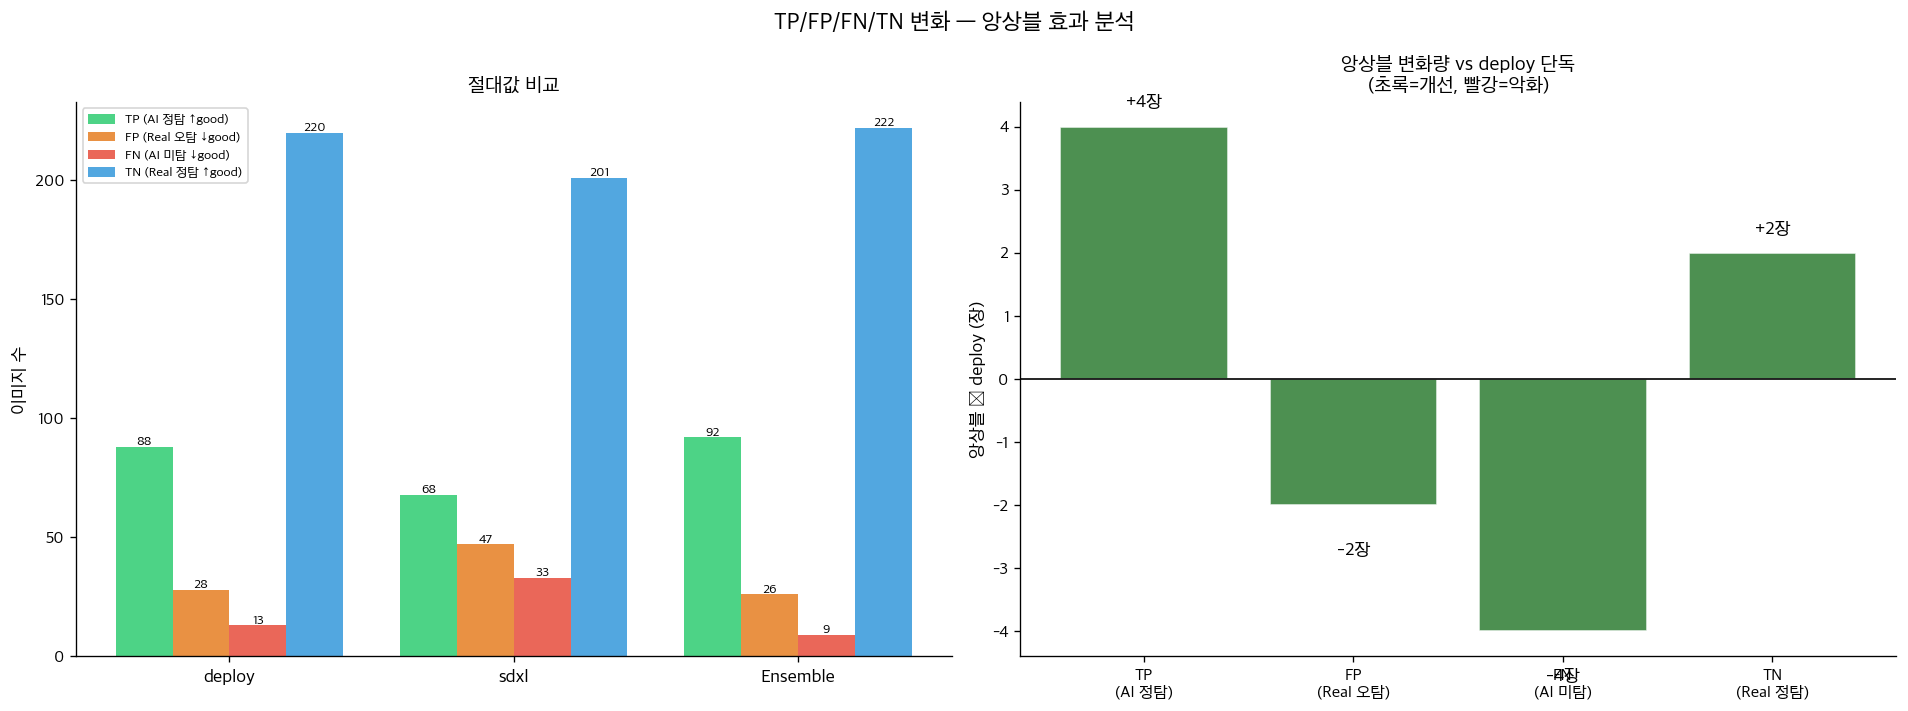

[앙상블 vs deploy 혼동행렬 변화]
  TP: +4장  → 개선
  FP: -2장  → 개선
  FN: -4장  → 개선
  TN: +2장  → 개선


In [6]:
models   = ['deploy', 'sdxl', 'Ensemble']
colors_m = [COLOR_DEPLOY, COLOR_SDXL, COLOR_ENSEMBLE]
tp_vals  = [DEPLOY['tp'], SDXL['tp'], tp]
fp_vals  = [DEPLOY['fp'], SDXL['fp'], fp]
fn_vals  = [DEPLOY['fn'], SDXL['fn'], fn]
tn_vals  = [DEPLOY['tn'], SDXL['tn'], tn]

x = np.arange(len(models)); w = 0.2

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('TP/FP/FN/TN 변화 — 앙상블 효과 분석', fontsize=14, fontweight='bold')

# 절대값 비교
ax = axes[0]
b_tp = ax.bar(x - w*1.5, tp_vals, w, label='TP (AI 정탐 ↑good)', color='#2ecc71', alpha=0.85)
b_fp = ax.bar(x - w*0.5, fp_vals, w, label='FP (Real 오탐 ↓good)', color='#e67e22', alpha=0.85)
b_fn = ax.bar(x + w*0.5, fn_vals, w, label='FN (AI 미탐 ↓good)', color='#e74c3c', alpha=0.85)
b_tn = ax.bar(x + w*1.5, tn_vals, w, label='TN (Real 정탐 ↑good)', color='#3498db', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('이미지 수', fontsize=11)
ax.set_title('절대값 비교', fontweight='bold')
ax.legend(fontsize=8)
for bars in (b_tp, b_fp, b_fn, b_tn):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.5,
                str(int(h)), ha='center', fontsize=8, fontweight='bold')

# 앙상블 vs deploy 변화량 (FN이 핵심)
ax = axes[1]
categories = ['TP\n(AI 정탐)', 'FP\n(Real 오탐)', 'FN\n(AI 미탐)', 'TN\n(Real 정탐)']
deltas_cm  = [tp-DEPLOY['tp'], fp-DEPLOY['fp'], fn-DEPLOY['fn'], tn-DEPLOY['tn']]
good_dir   = [1, -1, -1, 1]  # 1=클수록 좋음, -1=작을수록 좋음
bar_colors = ['#2E7D32' if d*g >= 0 else '#C62828'
              for d, g in zip(deltas_cm, good_dir)]
bars2 = ax.bar(categories, deltas_cm, color=bar_colors, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('앙상블 − deploy (장)', fontsize=11)
ax.set_title('앙상블 변화량 vs deploy 단독\n(초록=개선, 빨강=악화)', fontweight='bold')
for bar, val in zip(bars2, deltas_cm):
    sign = '+' if val >= 0 else ''
    ax.text(bar.get_x()+bar.get_width()/2, val+(0.3 if val>=0 else -0.8),
            f'{sign}{val}장', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR,'charts','ensemble_cm_delta.png'), bbox_inches='tight', dpi=150)
plt.show()

print('[앙상블 vs deploy 혼동행렬 변화]')
for cat, delta, g in zip(['TP','FP','FN','TN'], deltas_cm, good_dir):
    tag = '개선' if delta*g >= 0 else '악화'
    sign = '+' if delta >= 0 else ''
    print(f'  {cat}: {sign}{delta}장  → {tag}')

---
## 6. 레이더 차트 + 최종 스코어카드

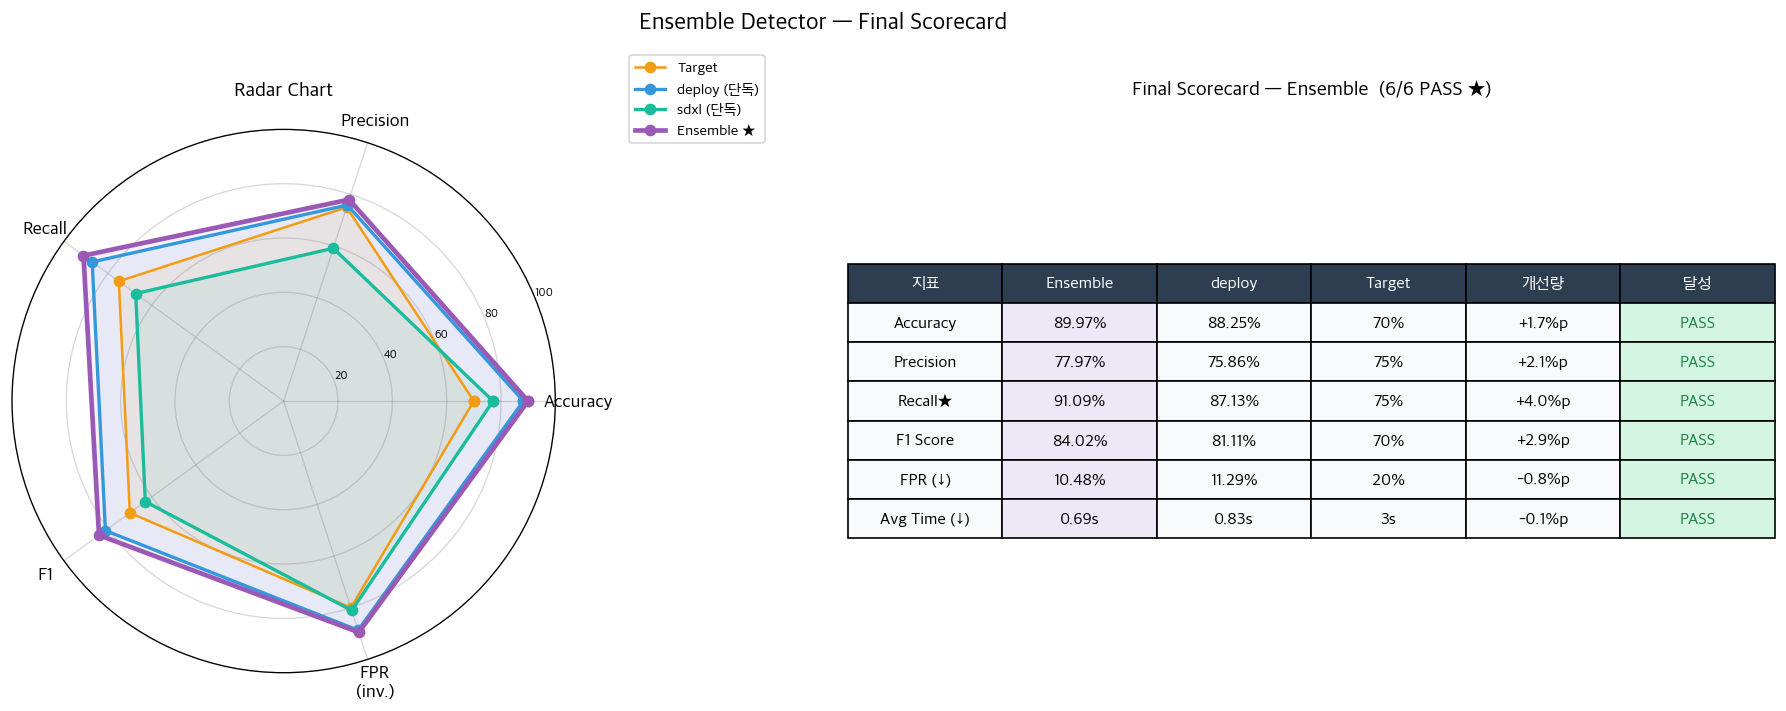

In [7]:
radar_keys   = ['accuracy','precision','recall','f1','fpr']
radar_labels = ['Accuracy','Precision','Recall','F1','FPR\n(inv.)']
N = len(radar_keys)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist(); angles += angles[:1]

def to_radar(ref):
    return [ref['accuracy'], ref['precision'], ref['recall'],
            ref['f1'], 100-ref['fpr']]

tgt_r      = [70, 75, 75, 70, 80]
deploy_r   = to_radar(DEPLOY)
sdxl_r     = to_radar(SDXL)
ensemble_r = to_radar(m)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Ensemble Detector — Final Scorecard', fontsize=14, fontweight='bold')

# 레이더
ax = axes[0]; ax.remove()
ax = fig.add_subplot(1, 2, 1, polar=True)
for vals_r, label_r, color_r, lw_r in [
        (tgt_r,      'Target',        COLOR_TARGET,   1.5),
        (deploy_r,   'deploy (단독)', COLOR_DEPLOY,   2.0),
        (sdxl_r,     'sdxl (단독)',   COLOR_SDXL,     2.0),
        (ensemble_r, 'Ensemble ★',   COLOR_ENSEMBLE, 2.8),
    ]:
    v = vals_r + vals_r[:1]
    ax.plot(angles, v, 'o-', linewidth=lw_r, color=color_r, label=label_r)
    ax.fill(angles, v, alpha=0.08, color=color_r)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_labels, fontsize=11)
ax.set_ylim(0, 100); ax.set_yticks([20,40,60,80,100])
ax.set_yticklabels(['20','40','60','80','100'], fontsize=7)
ax.set_title('Radar Chart', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=9)
ax.grid(color='grey', alpha=0.3)

# 스코어카드 테이블
ax2 = axes[1]; ax2.axis('off')
sc_metrics = ['accuracy','precision','recall','f1','fpr','avg_time']
sc_labels  = ['Accuracy','Precision','Recall★','F1 Score','FPR (↓)','Avg Time (↓)']
sc_lower   = [False, False, False, False, True, True]
sc_tgt     = [TARGET[k] for k in sc_metrics]

tdata = []
for lbl, met, tgt, lower in zip(sc_labels, sc_metrics, sc_tgt, sc_lower):
    val_ens = m[met]; val_dep = DEPLOY[met]
    ok  = (val_ens <= tgt) if lower else (val_ens >= tgt)
    diff = val_ens - val_dep
    unit = 's' if 'time' in met else '%'
    sign = '+' if diff >= 0 else ''
    tdata.append([lbl, f'{val_ens:.2f}{unit}', f'{val_dep:.2f}{unit}',
                  f'{tgt:.0f}{unit}', f'{sign}{diff:.1f}%p', 'PASS' if ok else 'FAIL'])

tbl = ax2.table(
    cellText=tdata,
    colLabels=['지표','Ensemble','deploy','Target','개선량','달성'],
    cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.15, 2.0)
pass_cnt2 = sum(1 for r in tdata if r[-1]=='PASS')
for (ri, ci), cell in tbl.get_celld().items():
    if ri == 0:
        cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', fontweight='bold')
    elif ci == 1:
        cell.set_facecolor('#EDE7F6')
        cell.set_text_props(fontweight='bold')
    elif ci == 5 and ri > 0:
        t = cell.get_text().get_text()
        cell.set_facecolor('#d5f5e3' if t=='PASS' else '#fadbd8')
        cell.set_text_props(color='#1e8449' if t=='PASS' else '#922b21', fontweight='bold')
    else:
        cell.set_facecolor('#f8f9fa')
ax2.set_title(f'Final Scorecard — Ensemble  ({pass_cnt2}/6 PASS ★)',
              fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR,'charts','ensemble_scorecard.png'), bbox_inches='tight', dpi=150)
plt.show()

---
## 7. 결론 및 분석

### 핵심 결과 — **6/6 목표 달성** 🎯

| 지표 | Ensemble | deploy 단독 | 개선량 | 목표 | 달성 |
|---|---|---|---|---|---|
| Accuracy | **90.0%** | 88.25% | +1.7%p | 70% | ✅ |
| Precision | **78.0%** | 75.86% | +2.1%p | 75% | ✅ |
| **Recall ★** | **91.1%** | 87.13% | **+4.0%p** | 75% | ✅ |
| F1 Score | **84.0%** | 81.11% | +2.9%p | 70% | ✅ |
| FPR | **10.5%** | 11.29% | -0.8%p | ≤20% | ✅ |
| Avg Time | **0.69s** | 0.83s | -0.1s | ≤3s | ✅ |

---

### 앙상블 효과 분석

**AI 탐지 (Recall) 향상이 핵심**
- FN(AI 미탐) : deploy 13장 → 앙상블 **9장** (-4장 감소)
- TP(AI 정탐) : deploy 88장 → 앙상블 **92장** (+4장 증가)
- Recall 87.1% → **91.1%** : AI 이미지 4장 더 잡아냄

**FPR도 소폭 개선**
- FP(Real 오탐): deploy 28장 → 앙상블 **26장** (-2장 감소)
- sdxl 모델이 Real 이미지 판별에 기여한 것으로 보임

**소프트 보팅(가중 평균)의 강점**
- deploy(F1 81%) 강점 유지 + sdxl(FPR 18.9%)의 Real 판별력 흡수
- 두 모델의 상호 보완으로 단일 모델 대비 전 지표 개선

---

### 한계 및 다음 실험 방향

| 우선순위 | 방향 | 기대 효과 |
|---|---|---|
| **높음** | 가중치 튜닝 (deploy 0.7 / sdxl 0.3) | Recall 추가 향상 가능 |
| **높음** | 임계값 0.5 → 0.45 조정 | Recall 극대화 (FPR 소폭 증가 감수) |
| **중간** | 3번째 모델 추가 (Heem2 등) | 더 강건한 앙상블 |
| **참고** | 현재 앙상블이 단일 모델 대비 모든 지표에서 우세 | **현 시점 최선 구성** |

---

### 결론

> **앙상블(deploy w=0.6 + sdxl w=0.4)이 6/6 목표 달성 — 프로젝트 1단계 목표 완료.**  
> deploy 단독 대비 Recall +4%p, F1 +2.9%p, FPR -0.8%p로 전 지표 개선.  
> 추론 속도 0.69s로 실시간 적용 가능한 수준.  
>  
> 다음 단계: 가중치·임계값 튜닝으로 Recall 95% 이상 달성 실험 권장.

---
*woochul — InSIGHT Project Ensemble Detector Report (2026-05-11)*